## Лабораторна робота №1 “Linear Regression”
#### Мета: навчитись реалізовувати лінійну регресію та градієнтний спуск.
#### Завдання:

1. Викачати дані з https://drive.google.com/drive/folders/17Xwk2quPb1gFmjG3KVIoZqChrWdcZ8XS?usp=sharing

In [50]:
import numpy as np
import matplotlib.pyplot as plt

train_data = np.loadtxt('lab_1_train.csv', delimiter=',', skiprows=1)
test_data = np.loadtxt('lab_1_test.csv', delimiter=',', skiprows=1)

train_X = train_data[:, 1]
train_y = train_data[:, 2]

test_X = test_data[:, 1]
test_y = test_data[:, 2]

2. Реалізувати лінійну регресію, яка за допомогою даних з колонки “x” прогнозує значення в колонці “y” (перша колонка у файлах - просто індекс, не ознака, не потрібно її використовувати). Тренування алгоритму повинно відбуватись лише на даних з train датасету. Test датасет слугує для перевірки якості вже натренованої моделі.

    a) Візуалізувати дані з lab1_train.csv.

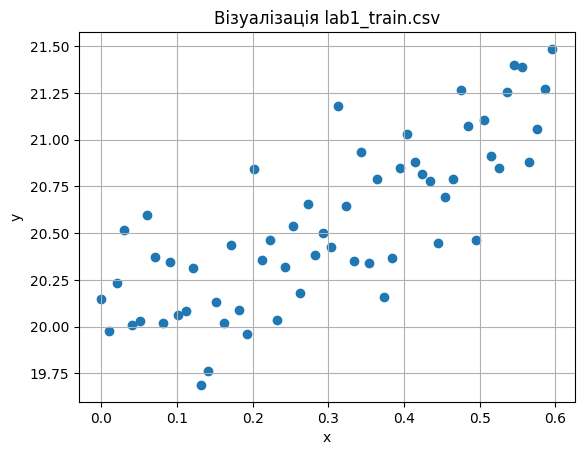

In [51]:
plt.scatter(train_X, train_y)
plt.title('Візуалізація lab1_train.csv')
plt.xlabel('x'); plt.ylabel('y')
plt.grid()
plt.show()

    b) Після кожної епохи виводити поточні значення ваг та функції втрат. Використовувати Mean Squared Error як функцію втрат.

In [52]:
b0 = b1 = 0.0
alpha = 0.01 
J_eps = 0.000001
prev_J = float('inf')
m = len(train_X)
epoch = 0 

print("Початок градієнтного спуску:")
while True:
    pred_y = b0 + b1 * train_X
    
    e =  pred_y - train_y
    J = (1 / (2 * m)) * np.sum(e ** 2)
    
    print(f"Епоха {epoch}: b0 = {b0:.5f}, b1 = {b1:.5f}, J = {J:.5f}")
    

    if abs(prev_J - J) < J_eps:
        print(f"Умова збіжності виконана на епосі {epoch}")
        break
        
    prev_J = J
    
    dJ_db0 = (1 / m) * np.sum(e)
    dJ_db1 = (1 / m) * np.sum(e * train_X)
    
    b0 = b0 - alpha * dJ_db0
    b1 = b1 - alpha * dJ_db1
    
    epoch += 1

Початок градієнтного спуску:
Епоха 0: b0 = 0.00000, b1 = 0.00000, J = 211.23870
Епоха 1: b0 = 0.20550, b1 = 0.06184, J = 206.65858
Епоха 2: b0 = 0.40875, b1 = 0.12299, J = 202.17788
Епоха 3: b0 = 0.60979, b1 = 0.18347, J = 197.79444
Епоха 4: b0 = 0.80864, b1 = 0.24327, J = 193.50616
Епоха 5: b0 = 1.00533, b1 = 0.30241, J = 189.31096
Епоха 6: b0 = 1.19987, b1 = 0.36089, J = 185.20683
Епоха 7: b0 = 1.39229, b1 = 0.41872, J = 181.19179
Епоха 8: b0 = 1.58262, b1 = 0.47591, J = 177.26391
Епоха 9: b0 = 1.77087, b1 = 0.53247, J = 173.42129
Епоха 10: b0 = 1.95707, b1 = 0.58840, J = 169.66208
Епоха 11: b0 = 2.14124, b1 = 0.64370, J = 165.98447
Епоха 12: b0 = 2.32341, b1 = 0.69839, J = 162.38670
Епоха 13: b0 = 2.50359, b1 = 0.75247, J = 158.86702
Епоха 14: b0 = 2.68180, b1 = 0.80595, J = 155.42375
Епоха 15: b0 = 2.85808, b1 = 0.85884, J = 152.05522
Епоха 16: b0 = 3.03243, b1 = 0.91114, J = 148.75981
Епоха 17: b0 = 3.20489, b1 = 0.96285, J = 145.53593
Епоха 18: b0 = 3.37547, b1 = 1.01399, J = 142

c) Після того, як градієнтний спуск зійшовся, порахувати функцію втрат на тестових даних з lab1_test.csv.

In [53]:
pred_test_y = b0 + b1 * test_X
test_J = (1 / (2 * m)) * np.sum((test_y - pred_test_y) ** 2)
print(f"J на lab1_test.csv: {test_J:.5f}")

J на lab1_test.csv: 0.03010


d) Візуалізувати на одному графіку дані з lab1_train.csv,  lab1_test.csv та лінію, до якої зійшовся розв’язок.

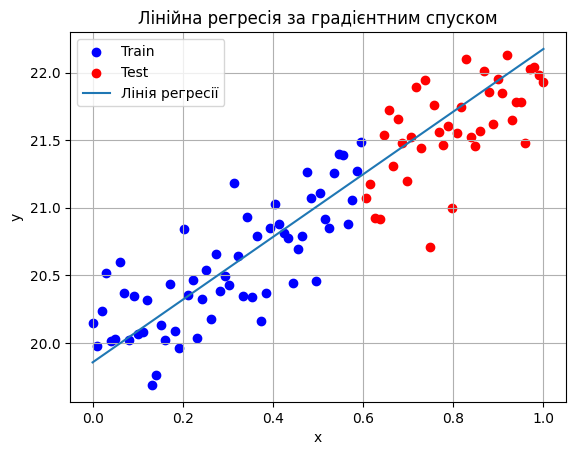

In [54]:
plt.scatter(train_X, train_y, color='blue', label='Train')
plt.scatter(test_X, test_y, color='red', label='Test')

x_min = min(np.min(train_X), np.min(test_X))
x_max = max(np.max(train_X), np.max(test_X))
x_line = np.array([x_min, x_max])
y_line = b0 + b1 * x_line

plt.plot(x_line, y_line, label='Лінія регресії')
plt.title('Лінійна регресія за градієнтним спуском')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

Формулою Оптимального Визначення Ваги

In [55]:
w1 = (np.sum(train_X * train_y) - (1 / n) * np.sum(train_X) * np.sum(train_y)) / (np.sum(train_X ** 2) - (1 / n) * (np.sum(train_X) ** 2))
w0 = np.mean(train_y) - w1 * np.mean(train_X)

print(f"w0 = {w0:.5f}, w1 = {w1:.5f}")

w0 = 19.95993, w1 = 1.97878


Порівняння оптимального і градієнтного методів визначення вагів

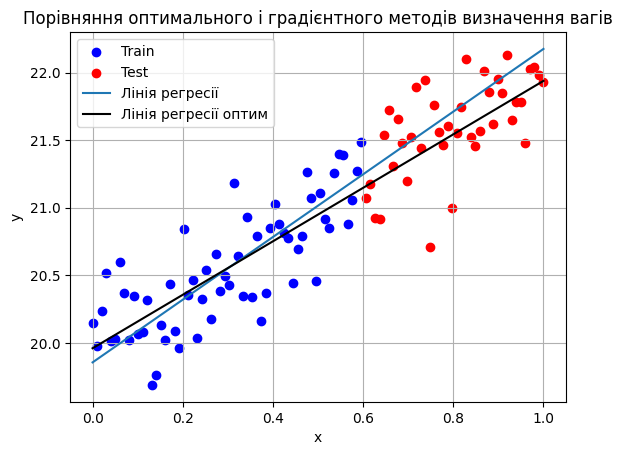

In [56]:
plt.scatter(train_X, train_y, color='blue', label='Train')
plt.scatter(test_X, test_y, color='red', label='Test')
y_line_opt = w0 + w1 * x_line

plt.plot(x_line, y_line_gr, label='Лінія регресії')
plt.plot(x_line, y_line_opt, color='black', label='Лінія регресії оптим')
plt.title('Порівняння оптимального і градієнтного методів визначення вагів')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()
plt.show()

## Висновок:

У ході виконання лабораторної роботи було успішно реалізовано алгоритм лінійної регресії. Під час роботи було налагоджено процес обчислення функції втрат та ітеративне оновлення ваг моделі, а також практично доведено важливість правильного підбору кроку alpha для успішного сходження алгоритму до глобального мінімуму. Обчислення похибки на тестовій вибірці та підсумкова візуалізація підтвердили, що побудована модель не лише мінімізувала помилку на тренувальних даних, але й здатна точно прогнозувати значення на нових, невідомих алгоритму даних.